In [1]:
import sys
sys.path.append("../")

from src import regmod
from src import solver

from src.utils import *

import nibabel as nib

In [2]:
save_plots = False

In [3]:
img = nib.load('/Users/mikichan/Desktop/mywork/data_resources/atlas_data/f-tract_v2112/lausanne2008_33-meta/region_masks.nii')
masks_volume = img.get_fdata()
regions_centroid = np.array([np.array(np.where(masks_volume == r)).T.mean(axis=0) for r in range(1, int(masks_volume.max()) + 1)])

In [5]:
importpath = '/Users/mikichan/Desktop/mywork/data_resources/atlas_data/f-tract_v2112/ages_15_100-sorted/Lausanne2008-33/atlas__ages_15_100__sr_8.40__seg_None_None__pl_200__Lausanne2008-33.pkl'

with open(importpath, 'rb') as f:
    data = pickle.load(f)

/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_4665/2631873594.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


In [16]:
duration = data[4]

## Description

Testing sparsifying scheme and observe the regression of delays' results. 

Performed on :
- f-tract

## F-tract Example

In [ ]:
'/Users/mikichan/Desktop/mywork/data_resources/atlas_data/f-tract_v2112/ages_15_100-sorted/Lausanne2008-33/'

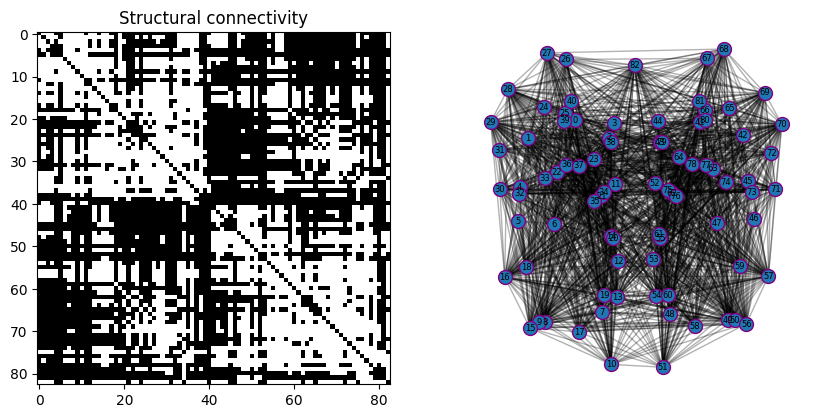

In [57]:
path_to_data = "../resources"

# Could be 50, 100, 200, 400
delay_max = 400
path_to_ftract = f"/Users/mikichan/Desktop/mywork/data_resources/atlas_data/f-tract_v2112/F-TRACT-090624/{delay_max}"
# path_to_ftract = f"/Users/acionca/data/F-TRACT-090624/{delay_max}"
path_to_ftract_compare = op.join(path_to_ftract, f"../{100}")

filename = "bundle_probability_atlas.pkl"

adj = load(op.join(path_to_data, filename))

adj = adj[:83, :83]
adj -= np.diag(np.diag(adj))
N = adj.shape[0]

bundle_prob_thresh = 0.9

adj = (adj > bundle_prob_thresh).astype(int)

bundle_prob = load(op.join(path_to_data, "bundle_probability_atlas.pkl"))
bundle_prob = bundle_prob[:83, :83]
bundle_prob -= np.diag(np.diag(bundle_prob))
ftract_prob = load(op.join(path_to_data, "adj_probability_ftract.pkl"))
ftract_prob = ftract_prob[:83, :83]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axes[0].imshow(adj, cmap='gray')
axes[0].set_title('Structural connectivity')
toy_graph = nx.Graph(adj)
pos = {i: regions_centroid[i][:2] for i in range(len(regions_centroid))}
# draw nodes, edges with transparency, and labels
nx.draw_networkx_nodes(toy_graph, pos=pos, ax=axes[1], node_size=100, edgecolors='purple')
nx.draw_networkx_edges(toy_graph, pos=pos, ax=axes[1], alpha=0.3, edge_color='black')
nx.draw_networkx_labels(toy_graph, pos=pos, ax=axes[1], font_size=6)
axes[1].set_axis_off()

In [58]:
importlib.reload(regmod)
# Pre-Compute design matrices
max_path_depth = 1

if op.exists(op.join(path_to_data, f"design_matrices_maxdepth{max_path_depth}.pkl")):
    design_matrices = load(op.join(path_to_data, f"design_matrices_maxdepth{max_path_depth}.pkl"))
else:
    design_matrices = regmod.get_shortest_matrices(adj, max_path_depth, progress=True)
    save(op.join(path_to_data, f"design_matrices_maxdepth{max_path_depth}.pkl"), design_matrices)

### Sanity check

In [75]:
reduced_adj = deepcopy(adj)

x_ground = remove_diagonal_entries(reduced_adj).flatten()

a = 0.5
# Computes the alpha vector as alpha_n = a^n
alpha = solver.torch.tensor([a**(i+1) for i in range(max_path_depth)])

design_shortest = regmod.build_design_shortest(reduced_adj, n_subopt=max_path_depth - 1, alpha=a)
design_model = solver.torch.tensor(design_shortest)
x_ground = remove_diagonal_entries(reduced_adj).flatten().astype(float)
y_pred = solver.forward(design_model, solver.torch.tensor(x_ground)).numpy()

  0%|          | 0/6806 [00:00<?, ?it/s]

In [77]:
y_pred = solver.forward(design_model, solver.torch.tensor(x_ground))
y_ground = solver.torch.tensor(deepcopy(y_pred))

init_pseudo = False
if init_pseudo:
    x_pseudo = solver.pseudo_inverse(y_pred.numpy(), a_design=design_model.numpy())
    x_init = solver.torch.tensor(x_pseudo).requires_grad_(True)
else:
    np.random.seed(99)
    x_init = solver.torch.tensor(np.random.rand(len(x_ground))).requires_grad_(True)

/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_98901/2920199660.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_ground = solver.torch.tensor(deepcopy(y_pred))


In [78]:
# Checking for zero entries in the y vector (conduction delays)
# As we cannot fit those values, we remove them from the regression
# (equivalent to removing the corresponding rows in the design matrix) 
non_zero_mask = y_ground > 0

y_masked = y_ground[non_zero_mask]
design_model_masked = design_model[non_zero_mask]

In [81]:
x = deepcopy(x_init)
x_opt, loss, loss_logs, df_loss = solver.gradient_descent_solver(x, y_masked, design_model_masked,
                                            n_iter=5000, verbose=False, 
                                            early_stop=1e-10, step_size=5e-2,
                                            l2_penalty=5e-1, return_logs=True)

(<Figure size 1000x500 with 4 Axes>,
 <Axes: title={'center': 'Estimated Effective delays w/ loss=0.5342'}>)

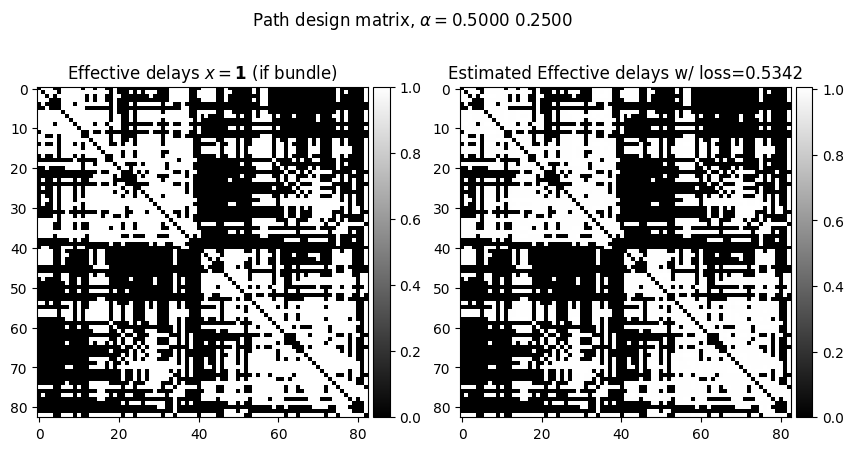

In [82]:
x_ground_mat = add_diagonal_entries(x_ground.reshape(reduced_adj.shape[0], reduced_adj.shape[1]-1))
x_pred_mat = add_diagonal_entries(x_opt.reshape(reduced_adj.shape[0], reduced_adj.shape[1]-1))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
fig.suptitle(rf"Path design matrix, $\alpha=$"+" ".join([f"{a:1.4f}" for a in list(alpha)]))
axes[0].imshow(x_ground_mat, cmap='gray')
axes[0].set_title("Effective delays $x=\mathbf{1}$ (if bundle)")
add_cbar(fig, axes[0])
# utils.annotate_heatmap(fig, axes[0], x_ground_mat, adapt_color=0.6)

axes[1].imshow(x_pred_mat, cmap='gray')#, vmax=y_pred_mat.max())
axes[1].set_title(f"Estimated Effective delays w/ loss={np.round(loss,4)}")
add_cbar(fig, axes[1])
# annotate_heatmap(fig, axes[1], np.round(x_pred_mat,4), adapt_color=0.6)

Text(0.5, 0, 'Delay differences')

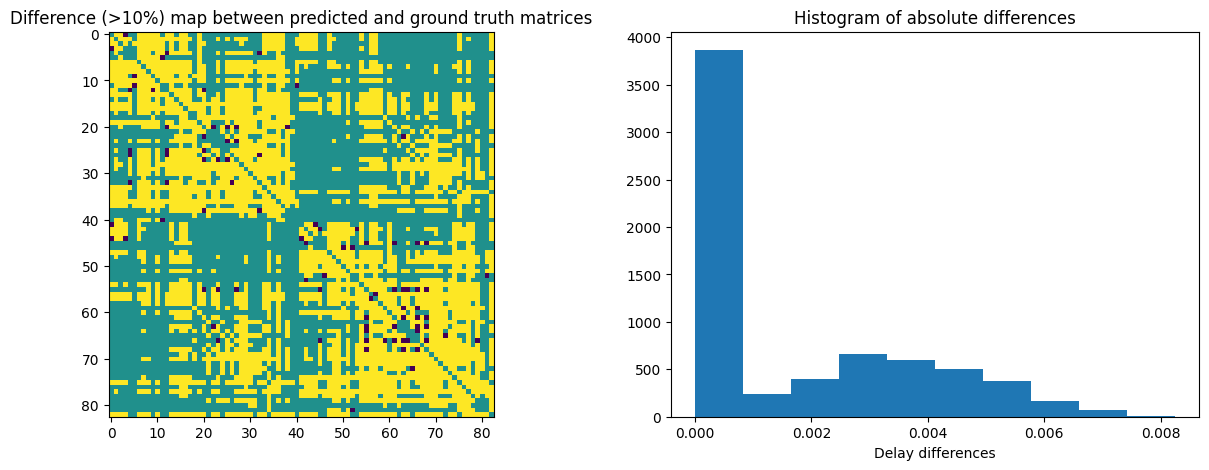

In [83]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
#ax.imshow(np.abs(x_pred_mat - x_ground_mat) > 0.1)
ax[0].imshow(x_pred_mat - x_ground_mat, vmin=-1e-5, vmax=1e-5)
ax[0].set_title('Difference (>10%) map between predicted and ground truth matrices')
ax[1].hist(np.abs(x_pred_mat - x_ground_mat).flatten())
ax[1].set_title('Histogram of absolute differences')
ax[1].set_xlabel('Delay differences')

In [84]:
y_est_opt = solver.forward(design_model, solver.torch.tensor(x_opt)).numpy()

y_est_mat = add_diagonal_entries(y_est_opt.reshape(reduced_adj.shape[0], reduced_adj.shape[1]-1))
y_ground_mat = add_diagonal_entries(y_ground.numpy().reshape(reduced_adj.shape[0], reduced_adj.shape[1]-1))

Text(0.5, 1.0, 'Ground truth conduction delays matrix')

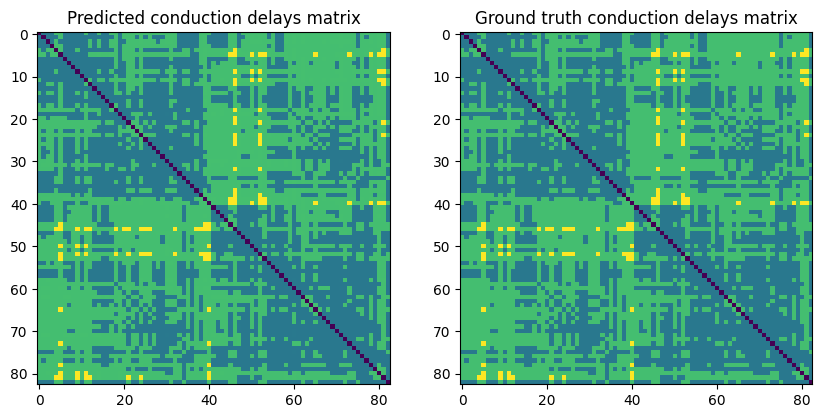

In [85]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].imshow(y_est_mat, vmin=0, vmax=y_ground_mat.max())
ax[0].set_title('Predicted conduction delays matrix')
ax[1].imshow(y_ground_mat, vmin=0, vmax=y_ground_mat.max())
ax[1].set_title('Ground truth conduction delays matrix')

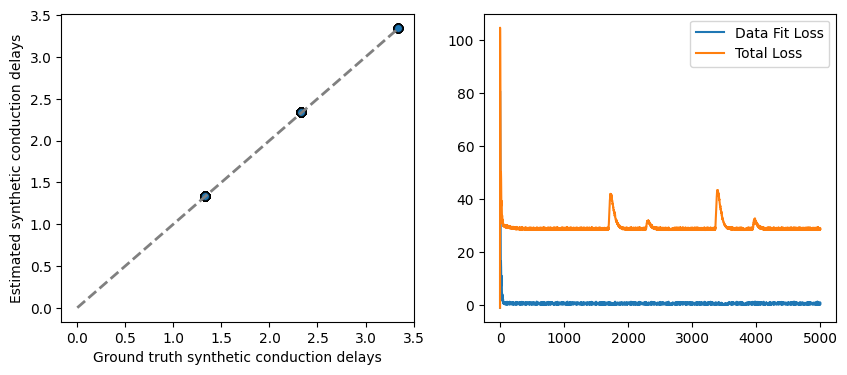

In [95]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
y_est_opt = solver.forward(design_model_masked, solver.torch.tensor(x_opt)).numpy()
ax[0].scatter(y_masked.numpy(), y_est_opt, edgecolor='k', alpha=0.7)
ax[0].plot(np.linspace(0,y_masked.max()), np.linspace(0,y_masked.max()), linestyle='--', color="gray", linewidth=2, label="1:1")
ax[0].set_xlabel('Ground truth synthetic conduction delays')
ax[0].set_ylabel('Estimated synthetic conduction delays')

ax[1].plot(df_loss, label='Data Fit Loss')
ax[1].plot(loss_logs, label='Total Loss')
ax[1].legend()

### From conductance delay

In [59]:
# conductance delay to regress
with open(op.join(path_to_ftract, 'peak_delay__median.txt')) as f:
    text = f.readlines()

y_ground_mat = []
for t in text[8:]:
    y_ground_mat.append(t.split(' '))
y_ground_mat = np.array(y_ground_mat).astype(float)
y_ground_mat = np.nan_to_num(y_ground_mat[:-1, :-1])

prob_thresh = 0
y_ground_mat *= ftract_prob > prob_thresh
y_ground = solver.torch.tensor(remove_diagonal_entries(y_ground_mat).flatten())

# conductance delay to compare (w/ shorter delay thus mimicking monosynaptic connections)
with open(op.join(path_to_ftract_compare, 'peak_delay__median.txt')) as f:
    text = f.readlines()

y_ground_mat_compare = []
for t in text[8:]:
    y_ground_mat_compare.append(t.split(' '))
y_ground_mat_compare = np.array(y_ground_mat_compare).astype(float)
y_ground_mat_compare = np.nan_to_num(y_ground_mat_compare[:-1, :-1])

prob_thresh = 0
y_ground_mat_compare *= ftract_prob > prob_thresh
y_ground_compare = solver.torch.tensor(remove_diagonal_entries(y_ground_mat_compare).flatten())

#### Modelling with alpha design matrix

In [60]:
a = 0.8

design_shortest = regmod.apply_alpha_to_design(design_matrix=design_matrices, n_subopt=max_path_depth, alpha=a)
design_model = solver.torch.tensor(design_shortest)

non_zero_mask = y_ground > 0

y_masked = y_ground[non_zero_mask]
design_model_masked = design_model[non_zero_mask]

In [61]:
np.random.seed(99)
x_init = solver.torch.tensor(np.random.rand(len(y_ground))).requires_grad_(True)

x = deepcopy(x_init)
x_opt, loss, loss_logs, df_loss = solver.gradient_descent_solver(x, y_masked, design_model_masked,
                                            n_iter=10000, verbose=False, 
                                            early_stop=1e-10, step_size=5e-1, delta=0,
                                            l2_penalty=1, return_logs=True)

Stopped at iteration #3907


(<Figure size 1000x500 with 4 Axes>,
 <Axes: title={'center': 'Effective delays $x$ (loss=0.6506 ms/edge)'}>)

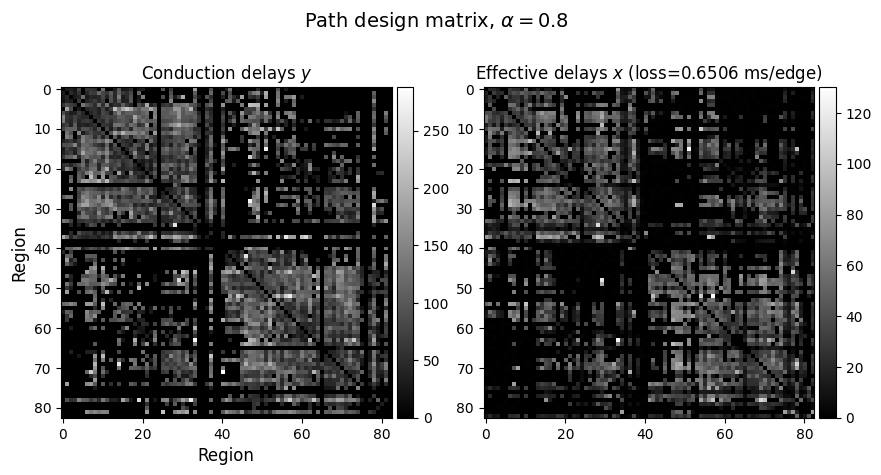

In [64]:
x_pred_mat = add_diagonal_entries(x_opt.reshape(adj.shape[0], adj.shape[1]-1))

fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
fig.suptitle(rf"Path design matrix, $\alpha={a}$", fontsize=14)

axes[0].imshow(y_ground_mat, cmap='gray')
axes[0].set_title(f"Conduction delays $y$", fontsize=12)
axes[0].set_xlabel("Region", fontsize=12)
axes[0].set_ylabel("Region", fontsize=12)
add_cbar(fig, axes[0])
# utils.annotate_heatmap(fig, axes, np.round(x_pred_mat,4), adapt_color=0.6)

prop_loss = loss / np.sum(y_ground_mat != 0)
axes[1].imshow(x_pred_mat, cmap='gray')
axes[1].set_title(f"Effective delays $x$ (loss={np.round(prop_loss,4)} ms/edge)", fontsize=12)
add_cbar(fig, axes[1])

#axes[2].imshow(x_pred_mat, cmap='gray', vmin=0)
#axes[2].set_title(f"Clipped $\hat y$")
#utils.add_cbar(fig, axes[2])

# if save_plots:
#     fig.savefig(f"../figures/estimated_delays_a{a}.png", dpi=300)

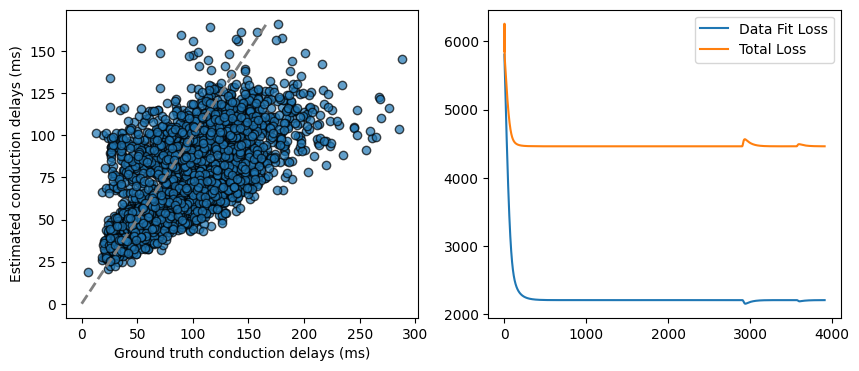

In [65]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
y_est_opt = solver.forward(design_model_masked, solver.torch.tensor(x_opt)).numpy()
ax[0].scatter(y_masked.numpy(), y_est_opt, edgecolor='k', alpha=0.7)
ax[0].plot(np.linspace(0,y_est_opt.max()), np.linspace(0,y_est_opt.max()), linestyle='--', color="gray", linewidth=2, label="1:1")
ax[0].set_xlabel('Ground truth conduction delays (ms)')
ax[0].set_ylabel('Estimated conduction delays (ms)')

ax[1].plot(df_loss[1:], label='Data Fit Loss')
ax[1].plot(loss_logs[1:], label='Total Loss')
ax[1].legend()

/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_98901/1491238997.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  xy_mask1 = np.logical_and(x1_mask, y_mask).numpy().astype(bool)
/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_98901/1491238997.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  xy_mask2 = np.logical_and(x2_mask, y_mask).numpy().astype(bool)


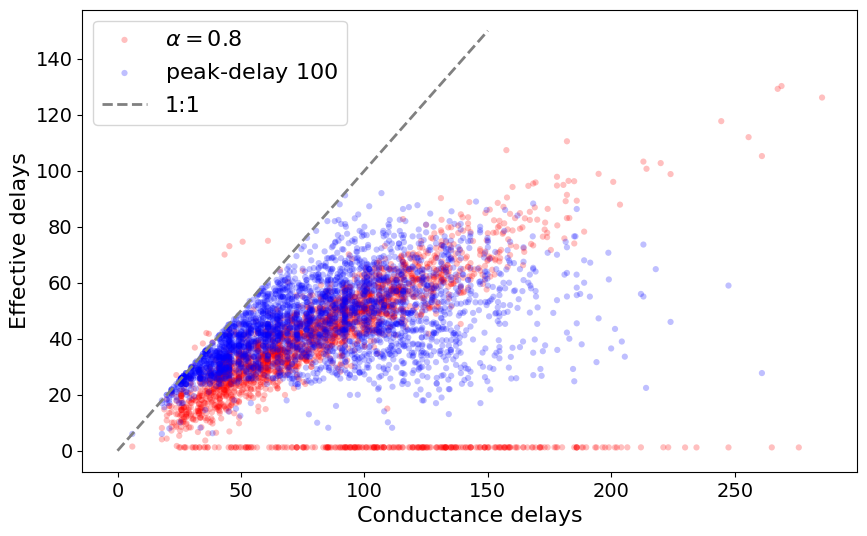

In [72]:
# plot the mapping curve and see what it looks like
x1 = x_opt
x2 = y_ground_compare
y = y_ground

x1_mask = x1 > 1
x2_mask = x2 > 1
y_mask = y != 0
xy_mask1 = np.logical_and(x1_mask, y_mask).numpy().astype(bool)
xy_mask2 = np.logical_and(x2_mask, y_mask).numpy().astype(bool)

fig, ax = plt.subplots(1,1, figsize=(10,6))

ax.scatter(y[xy_mask1], x1[xy_mask1], s=20, alpha=.25, edgecolors="none", color='red', label=r'$\alpha=0.8$')
ax.scatter(y[xy_mask2], x2[xy_mask2], s=20, alpha=.25, edgecolors="none", color='blue', label=r'peak-delay $100$')
# ax.scatter(y[~y_mask], x[~y_mask], s=100, alpha=.4, color="tab:brown", edgecolors="none")
# ax.scatter(y[~x_mask], x[~x_mask], s=100, alpha=.4, color="tab:purple", edgecolors="none")
ax.plot(np.linspace(0,150), np.linspace(0,150), linestyle='--', color="gray", linewidth=2, label="1:1")

ax.set_xlabel("Conductance delays", fontsize=16)
ax.set_ylabel("Effective delays", fontsize=16)
ax.tick_params(labelsize=14)
ax.legend(fontsize=16)

# ax.legend(["Non-zero", "Zero effective delays", "Zero conductance delays"], fontsize=16)
# ax.legend(["Non-zero"], fontsize=16)

# if save_plots:
#     fig.savefig("../figures/scatter-effective_conductance.png", dpi=300)

#### Modelling including $\delta$
TOFIX: we are currently using a different solver for this part than the one above

In [44]:
a = 0.8
design_shortest = regmod.apply_alpha_to_design(design_matrix=design_matrices, n_subopt=max_path_depth, alpha=a)

non_zero_mask = y_ground > 0
y_masked = y_ground[non_zero_mask]
design_model_masked = design_shortest[non_zero_mask]
design_model_masked = solver.torch.from_numpy(design_model_masked)

In [54]:
np.random.seed(99)
x_init = solver.torch.from_numpy(np.random.rand(len(y_ground))).requires_grad_(True)
delta_init = solver.torch.tensor(10.0).requires_grad_(True)

x_opt, delta_opt, loss, loss_logs, df_loss = solver.gradient_descent_solver_delta(x_init, y_masked, design_model_masked,
                                            n_iter=1000, verbose=False, 
                                            early_stop=1e-10, step_size=1, delta=delta_init,
                                            l2_penalty=0, return_logs=True)

  0%|          | 0/1000 [00:00<?, ?it/s]

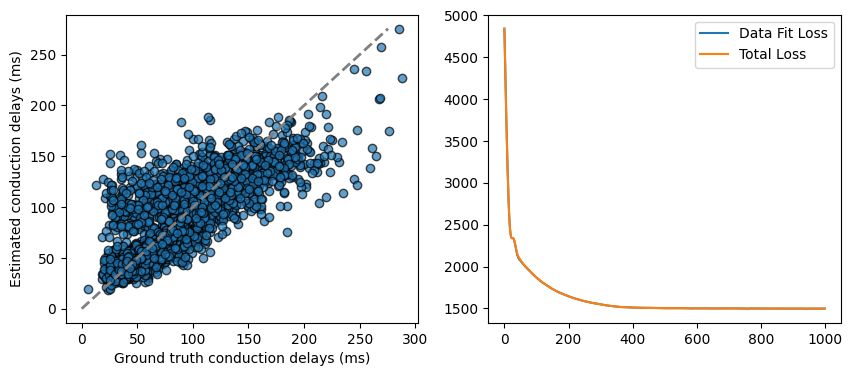

In [55]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
y_est_opt = solver.forward(design_model_masked, x_opt + delta_opt * (x_opt > 0)).numpy()

ax[0].scatter(y_masked.numpy(), y_est_opt, edgecolor='k', alpha=0.7)
ax[0].plot(np.linspace(0,y_est_opt.max()), np.linspace(0,y_est_opt.max()), linestyle='--', color="gray", linewidth=2, label="1:1")
ax[0].set_xlabel('Ground truth conduction delays (ms)')
ax[0].set_ylabel('Estimated conduction delays (ms)')

ax[1].plot(df_loss[1:], label='Data Fit Loss')
ax[1].plot(loss_logs[1:], label='Total Loss')
ax[1].legend()

(<Figure size 1000x500 with 4 Axes>,
 <Axes: title={'center': 'Effective delays $x$ (loss=0.4409 ms/edge)'}>)

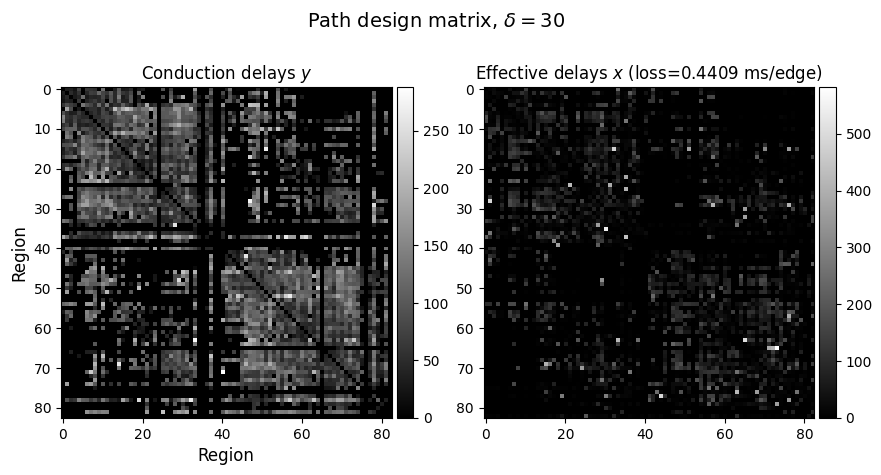

In [56]:
x_pred_mat = add_diagonal_entries(x_opt.reshape(adj.shape[0], adj.shape[1]-1))

fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
fig.suptitle(rf"Path design matrix, $\delta={30}$", fontsize=14)

axes[0].imshow(y_ground_mat, cmap='gray')
axes[0].set_title(f"Conduction delays $y$", fontsize=12)
axes[0].set_xlabel("Region", fontsize=12)
axes[0].set_ylabel("Region", fontsize=12)
add_cbar(fig, axes[0])
# utils.annotate_heatmap(fig, axes, np.round(x_pred_mat,4), adapt_color=0.6)

prop_loss = loss / np.sum(y_ground_mat != 0)
axes[1].imshow(x_pred_mat, cmap='gray')
axes[1].set_title(f"Effective delays $x$ (loss={np.round(prop_loss,4)} ms/edge)", fontsize=12)
add_cbar(fig, axes[1])

#axes[2].imshow(x_pred_mat, cmap='gray', vmin=0)
#axes[2].set_title(f"Clipped $\hat y$")
#utils.add_cbar(fig, axes[2])

# if save_plots:
#     fig.savefig(f"../figures/estimated_delays_a{a}.png", dpi=300)

/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_2574/4070363031.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  xy_mask1 = np.logical_and(x1_mask, y_mask).numpy().astype(bool)
/var/folders/9t/60tqjhtx2h55525lstv8nsc40000gn/T/ipykernel_2574/4070363031.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  xy_mask2 = np.logical_and(x2_mask, y_mask).numpy().astype(bool)


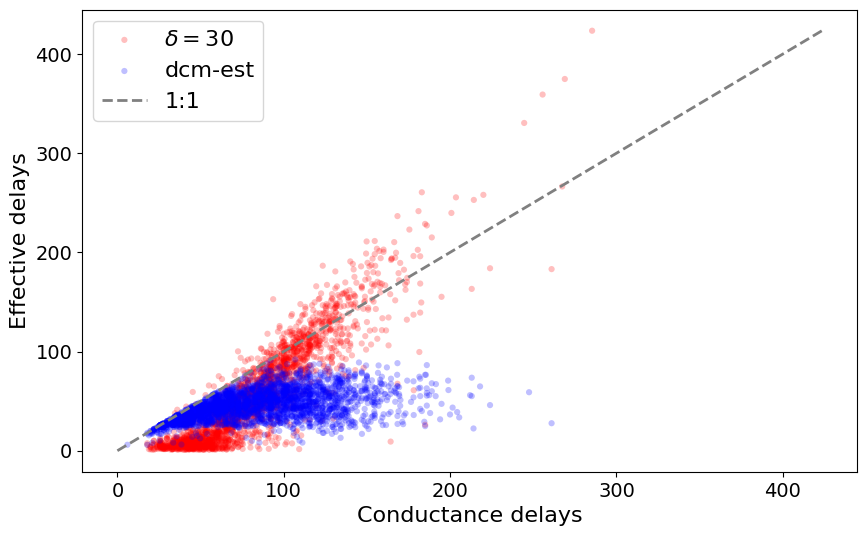

In [57]:
# plot the mapping curve and see what it looks like
x1 = x_opt
x2 = y_ground_compare
y = y_ground

x1_mask = x1 > 1
x2_mask = (x2 > 1) & (x2 < 100)
y_mask = y != 0
xy_mask1 = np.logical_and(x1_mask, y_mask).numpy().astype(bool)
xy_mask2 = np.logical_and(x2_mask, y_mask).numpy().astype(bool)

fig, ax = plt.subplots(1,1, figsize=(10,6))

ax.scatter(y[xy_mask1], x1[xy_mask1], s=20, alpha=.25, edgecolors="none", color='red', label=r'$\delta=30$')
ax.scatter(y[xy_mask2], x2[xy_mask2], s=20, alpha=.25, edgecolors="none", color='blue', label=r'dcm-est')
# ax.scatter(y[~y_mask], x[~y_mask], s=100, alpha=.4, color="tab:brown", edgecolors="none")
# ax.scatter(y[~x_mask], x[~x_mask], s=100, alpha=.4, color="tab:purple", edgecolors="none")
ax.plot(np.linspace(0,x1[xy_mask1].max()), np.linspace(0,x1[xy_mask1].max()), linestyle='--', color="gray", linewidth=2, label="1:1")

ax.set_xlabel("Conductance delays", fontsize=16)
ax.set_ylabel("Effective delays", fontsize=16)
ax.tick_params(labelsize=14)
ax.legend(fontsize=16)

# ax.legend(["Non-zero", "Zero effective delays", "Zero conductance delays"], fontsize=16)
# ax.legend(["Non-zero"], fontsize=16)

# if save_plots:
#     fig.savefig("../figures/scatter-effective_conductance.png", dpi=300)

#### Modify design matrix
Condition is that the edges in between need to have at least one point that is close to (in euclidean space) either the start or end of the edge.

Selecting indices to remove from each row i.e not to consider as path

110946 -> 100882 edges kept for design matrix 0
2750850 -> 671236 edges kept for design matrix 1


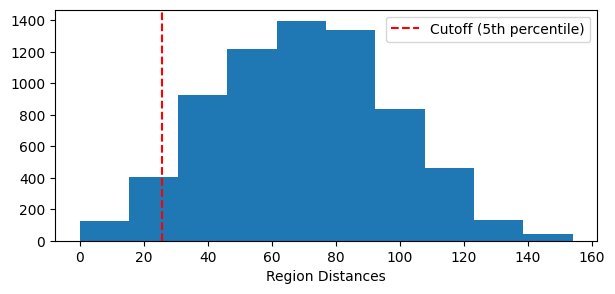

In [7]:
index_mat = np.zeros((N,N,2))
for i in range(N):
    for j in range(N):
        index_mat[i,j,0] = i
        index_mat[i,j,1] = j
bundle_index = index_mat[~np.eye(index_mat.shape[0],dtype=bool), :].astype(int)

# regions_centroid is already defined (N x 3)
centroid_coords = regions_centroid
centroid_dists = np.linalg.norm(centroid_coords[:, None, :] - centroid_coords[None, :, :], axis=2)
percentile = 0.05
cutoff = np.quantile(centroid_dists.flatten(), percentile)
fig, ax = plt.subplots(1, figsize=(7, 3))
ax.hist(centroid_dists.flatten())
ax.axvline(cutoff, color='red', linestyle='--', label=f'Cutoff ({percentile*100:.0f}th percentile)')
ax.set_xlabel('Region Distances')

ax.legend()
mask_designs = np.zeros_like(design_matrices, dtype=bool)
for k in range(design_matrices.shape[0]):
    design_k = design_matrices[k]
    for i in range(design_matrices.shape[1]):
        start, end = bundle_index[i]
        intermediate_indices = np.where(design_k[i])[0]
        intermediate_edges = bundle_index[intermediate_indices]
        for pidx, pair in enumerate(intermediate_edges):
            if centroid_dists[pair[0], start] < cutoff or centroid_dists[pair[1], end] < cutoff:
                mask_designs[k, i, intermediate_indices[pidx]] = True

print(f"{np.sum(design_matrices[0] > 0)} -> {np.sum(mask_designs[0])} edges kept for design matrix 0")
print(f"{np.sum(design_matrices[1] > 0)} -> {np.sum(mask_designs[1])} edges kept for design matrix 1")

initial_degrees = design_matrices.sum(axis=2)
masked_design_matrices = design_matrices * mask_designs
masked_design_matrices = (masked_design_matrices / masked_design_matrices.sum(axis=2)[:, :, None]) * initial_degrees[:, :, None]

Modelling with optimized delta

In [315]:
a = 0.8
design_shortest = regmod.apply_alpha_to_design(design_matrix=design_matrices, n_subopt=max_path_depth, alpha=a)
design_shortest_pruned = regmod.apply_alpha_to_design(design_matrix=masked_design_matrices, n_subopt=max_path_depth, alpha=a)

non_zero_mask = y_ground > 0
y_masked = y_ground[non_zero_mask]
design_model_masked = design_shortest[non_zero_mask]
design_model_masked = solver.torch.from_numpy(design_model_masked)

design_model_masked_pruned = design_shortest_pruned[non_zero_mask]
design_model_masked_pruned = solver.torch.from_numpy(design_model_masked_pruned)

print(f"{np.linalg.matrix_rank(design_model_masked.numpy())} -> {np.linalg.matrix_rank(design_model_masked_pruned.numpy())}")

3005 -> 3160


In [316]:
np.random.seed(99)
x_init = solver.torch.tensor(np.random.rand(len(y_ground))).requires_grad_(True)
delta_init = solver.torch.tensor(10.0).requires_grad_(True)

x = deepcopy(x_init)
delta = deepcopy(delta_init)
x_opt, delta_opt, loss, loss_logs, df_loss = solver.gradient_descent_solver_delta(x, y_masked, design_model_masked,
                                            n_iter=2000, verbose=False, 
                                            early_stop=1e-10, step_size=1, delta=delta,
                                            l2_penalty=0, return_logs=True)

x = deepcopy(x_init)
delta = deepcopy(delta_init)
x_opt_pruned, delta_opt_pruned, loss_pruned, loss_logs_pruned, df_loss_pruned = solver.gradient_descent_solver_delta(x, y_masked, design_model_masked_pruned,
                                            n_iter=2000, verbose=False, 
                                            early_stop=1e-10, step_size=1, delta=delta,
                                            l2_penalty=0, return_logs=True)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

(1470.0, 1550.0)

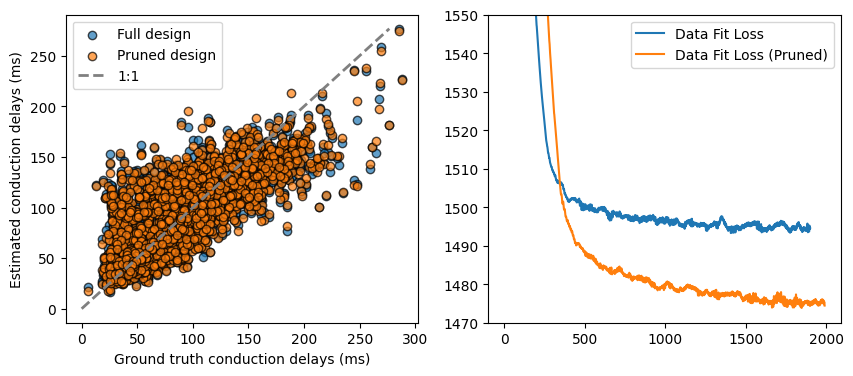

In [326]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

y_est_opt = solver.forward(design_model_masked, x_opt + delta_opt * (x_opt > 0)).numpy()
y_est_opt_pruned = solver.forward(design_model_masked_pruned, x_opt_pruned + delta_opt_pruned * (x_opt_pruned > 0)).numpy()

ax[0].scatter(y_masked.numpy(), y_est_opt, edgecolor='k', alpha=0.7, label='Full design')
ax[0].scatter(y_masked.numpy(), y_est_opt_pruned, edgecolor='k', alpha=0.7, label='Pruned design')

ax[0].plot(np.linspace(0,y_est_opt.max()), np.linspace(0,y_est_opt.max()), linestyle='--', color="gray", linewidth=2, label="1:1")
ax[0].set_xlabel('Ground truth conduction delays (ms)')
ax[0].set_ylabel('Estimated conduction delays (ms)')

ax[1].plot(df_loss[100:], label='Data Fit Loss')
# ax[1].plot(loss_logs[1:], label='Total Loss')
ax[1].plot(df_loss_pruned[10:], label='Data Fit Loss (Pruned)')
# ax[1].plot(loss_logs_pruned[1:], label='Total Loss (Pruned)')
# ax[1].set_yscale('log')
ax[0].legend()
ax[1].legend()
ax[1].set_ylim(1470, 1550)

In [8]:
non_zero_mask = y_ground > 0
y_masked = y_ground[non_zero_mask]

In [47]:
importlib.reload(solver)

np.random.seed(99)
x_init = solver.torch.tensor(np.random.rand(len(y_ground)), dtype=solver.torch.float32).requires_grad_(True)
alpha_init = solver.torch.tensor(0.0, dtype=solver.torch.float32).requires_grad_(True)
delta_init = solver.torch.tensor(10.0, dtype=solver.torch.float32).requires_grad_(True)

n_iter = 1000
x = deepcopy(x_init)
alpha = deepcopy(alpha_init)
delta = deepcopy(delta_init)
x_opt, (alpha_opt, delta_opt), loss, loss_logs, df_loss = solver.effective_delay_solver(x, y_masked, design=solver.torch.tensor(design_matrices), nzmask=non_zero_mask, alpha=alpha,
                                            n_iter=n_iter, verbose=False, 
                                            early_stop=1e-10, step_size=5e-1, delta=delta,
                                            l2_penalty=0, return_logs=True)

x = deepcopy(x_init)
alpha = deepcopy(alpha_init)
delta = deepcopy(delta_init)
x_opt_pruned, (alpha_opt_pruned, delta_opt_pruned), loss_pruned, loss_logs_pruned, df_loss_pruned = solver.effective_delay_solver(x, y_masked, design=solver.torch.tensor(masked_design_matrices), nzmask=non_zero_mask, alpha=alpha,
                                            n_iter=n_iter, verbose=False, 
                                            early_stop=1e-10, step_size=5e-1, delta=delta,
                                            l2_penalty=0, return_logs=True)

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [48]:
alpha_opt_pruned, delta_opt_pruned, alpha_opt, delta_opt

(0.5372152924537659, 4.719155788421631, 0.4900342524051666, 4.110581398010254)

In [49]:
design_model_masked = solver.apply_alpha_to_design_torch(solver.torch.tensor(design_matrices), alpha_opt)
design_model_masked = design_model_masked[non_zero_mask]

design_model_masked_pruned = solver.apply_alpha_to_design_torch(solver.torch.tensor(masked_design_matrices), alpha_opt_pruned)
design_model_masked_pruned = design_model_masked_pruned[non_zero_mask]

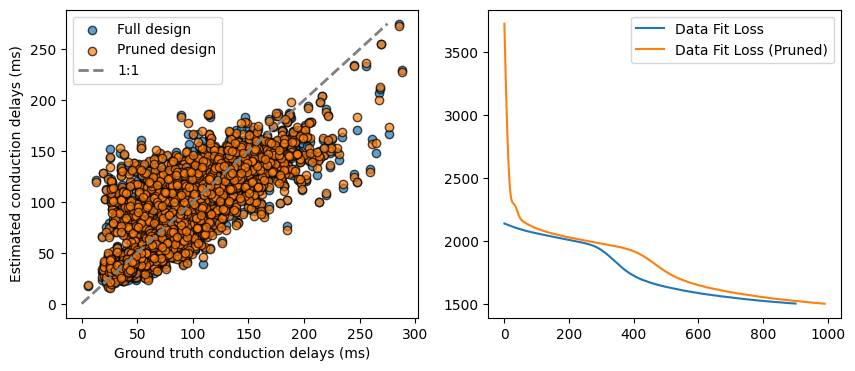

In [50]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

y_est_opt = solver.forward(design_model_masked, x_opt + delta_opt * (x_opt > 0)).numpy()
y_est_opt_pruned = solver.forward(design_model_masked_pruned, x_opt_pruned + delta_opt_pruned * (x_opt_pruned > 0)).numpy()

ax[0].scatter(y_masked.numpy(), y_est_opt, edgecolor='k', alpha=0.7, label='Full design')
ax[0].scatter(y_masked.numpy(), y_est_opt_pruned, edgecolor='k', alpha=0.7, label='Pruned design')

ax[0].plot(np.linspace(0,y_est_opt.max()), np.linspace(0,y_est_opt.max()), linestyle='--', color="gray", linewidth=2, label="1:1")
ax[0].set_xlabel('Ground truth conduction delays (ms)')
ax[0].set_ylabel('Estimated conduction delays (ms)')

ax[1].plot(df_loss[100:], label='Data Fit Loss')
# ax[1].plot(loss_logs[1:], label='Total Loss')
ax[1].plot(df_loss_pruned[10:], label='Data Fit Loss (Pruned)')
# ax[1].plot(loss_logs_pruned[1:], label='Total Loss (Pruned)')
# ax[1].set_yscale('log')
ax[0].legend()
ax[1].legend()

In [52]:
meta_joint_opt = {'y_est': y_est_opt, 'x_opt': x_opt, 'alpha_opt': alpha_opt, 'delta_opt': delta_opt, 'loss': loss, 'loss_logs': loss_logs, 'df_loss': df_loss}
meta_joint_opt_pruned = {'y_est': y_est_opt_pruned, 'x_opt': x_opt_pruned, 'alpha_opt': alpha_opt_pruned, 'delta_opt': delta_opt_pruned, 'loss': loss_pruned, 'loss_logs': loss_logs_pruned, 'df_loss': df_loss_pruned}

save(op.join(path_to_data, 'result_meta_joint.pkl'), meta_joint_opt)
save(op.join(path_to_data, 'result_meta_joint_pruned.pkl'), meta_joint_opt_pruned)